# Geometric Transforms and FeaturesCovers Hough line and circle detection, affine and perspective transforms, corner detection, and SIFT/ORB feature matching.

## Import libraries

In [1]:
# import Open CV library
import cv2

import matplotlib.pyplot as plt
import numpy as np

## Hough Line Detection
**Hough Transform** is one of the most powerful techniques for detecting lines. The Hough Transform is a feature extraction technique used to detect lines, circles, or other parametric shapes in an image.
It’s particularly useful for finding shapes even when they are partially broken, noisy, or not perfectly straight.

In OpenCV, it’s often applied after edge detection (usually with Canny).
### Probabilistic Hough Transform
The probabilistic version is a faster, optimized variant(that the standard).
Instead of voting for all pixels, it uses a random subset of edge points, making it much faster for large images.

Function:<br>
<code>linesP = cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)</code>
| Parameter         | Description                                |
| ----------------- | ------------------------------------------ |
| **image**         | Binary edge image                          |
| **rho**           | Distance resolution (pixels)               |
| **theta**         | Angle resolution (radians)                 |
| **threshold**     | Minimum number of votes                    |
| **minLineLength** | Minimum line segment length                |
| **maxLineGap**    | Max gap between line segments to link them |


Text(0.5, 1.0, 'Probabilistic Hough Lines')

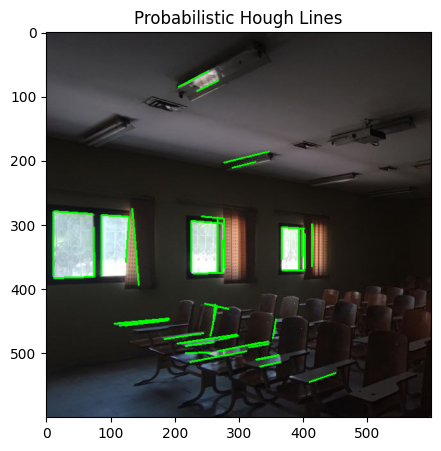

In [2]:
img = cv2.imread("images/classroom.jpg")
img = img[0:600,0:600]
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 1.4)
edges = cv2.Canny(blur,50,200)

linesP = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=20, minLineLength=30, maxLineGap=10)

output2 = img.copy()
for line in linesP:
    x1, y1, x2, y2 = line[0]
    cv2.line(output2, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(6,5))
plt.imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))
plt.title("Probabilistic Hough Lines")


## Hough Circle Detection
**The Hough Circle Transform** is an extension of the Hough Transform used to detect circular shapes in an image.

Unlike line detection (which uses a 2D parameter space ρ–θ), detecting circles requires a 3D parameter space(a,b,r)

Because searching a full 3D parameter space is extremely expensive, OpenCV uses an optimized algorithm based on gradient information, called **Hough Gradient Method**

Function:<br>
<code>circles = cv2.HoughCircles(
    img, 
    method, 
    dp, 
    minDist,
    param1,
    param2,
    minRadius,
    maxRadius
)
</code>

| Parameter     | Meaning                                                  |
| ------------- | -------------------------------------------------------- |
| **image**     | Grayscale input image                                    |
| **method**    |`cv2.HOUGH_GRADIENT`                          |
| **dp**        | Inverse ratio of resolution (1 = same res, 2 = half res) |
| **minDist**   | Minimum distance between detected centers                |
| **param1**    | Upper threshold for Canny edge detector                  |
| **param2**    | Accumulator threshold (lower → more circles)             |
| **minRadius** | Minimum circle radius                                    |
| **maxRadius** | Maximum circle radius                                    |


Text(0.5, 1.0, 'Detected Circles')

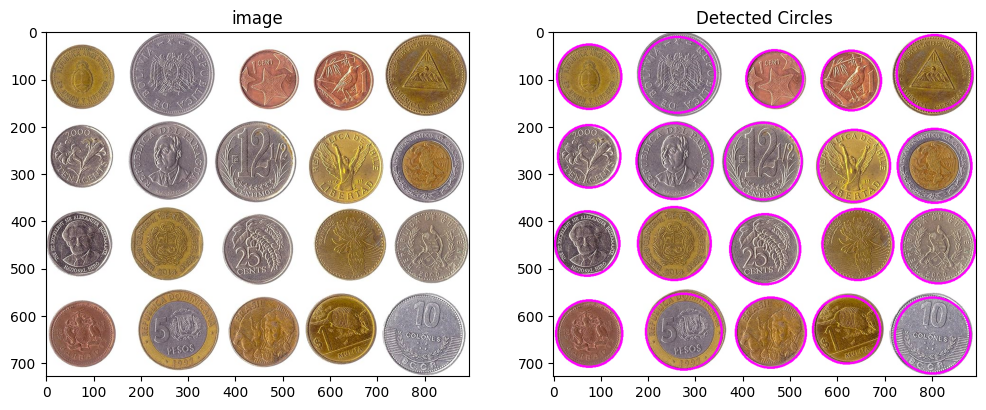

In [44]:
src = cv2.imread("images/Coins.jpg")
gray= cv2.cvtColor(src ,cv2.COLOR_RGB2GRAY)
gray= cv2.medianBlur(gray,3)

circles  = cv2.HoughCircles(gray,cv2.HOUGH_GRADIENT,1,minDist=gray.shape[0]//8,param1=100,param2=30,minRadius=60,maxRadius=82)

output = src.copy()

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        cv2.circle(output, (x, y), r, (255, 0, 255), 3)     

plt.figure(figsize=(12,5))
plt.subplot(121); plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB)); plt.title("image")
plt.subplot(122); plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.title("Detected Circles")

## Image Transformation
`cv2.warpAffine()` is an OpenCV function used to apply affine transformations to images.
Affine transformations preserve straight lines, parallelism, and ratios of distances, making them fundamental in image geometry.

Function:<br>
`dst = cv2.warpAffine(src, M, dsize, flags,
                     borderMode.BORDER_CONSTANT, borderValue)`
| Parameter       | Description                                |
| --------------- | ------------------------------------------ |
| **src**         | Input image                                |
| **M**           | 2×3 affine transformation matrix           |
| **dsize**       | Size of the output image `(width, height)` |
| **flags**       | Interpolation method (e.g. `INTER_LINEAR`) |
| **borderMode**  | How to handle pixels outside image         |
| **borderValue** | Fill value if using constant border        |



Text(0.5, 1.0, 'Rotated Image')

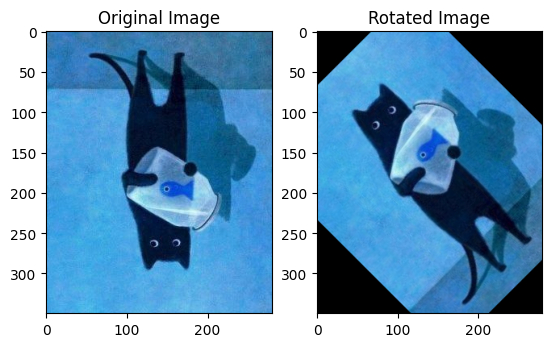

In [ ]:
img = cv2.imread("images/Cat.jpg")
h, w = img.shape[:2]

# Rotate around center by 45°, scale=1.0
# rotated = cv2.warpAffine(img, M, (width, height))
M = cv2.getRotationMatrix2D((w//2, h//2), 45, 1.0)

rotated = cv2.warpAffine(img, M, (w, h))

plt.subplot(121); plt.imshow(img); plt.title("Original Image")
plt.subplot(122); plt.imshow(rotated); plt.title("Rotated Image")

Text(0.5, 1.0, 'Transformed Image')

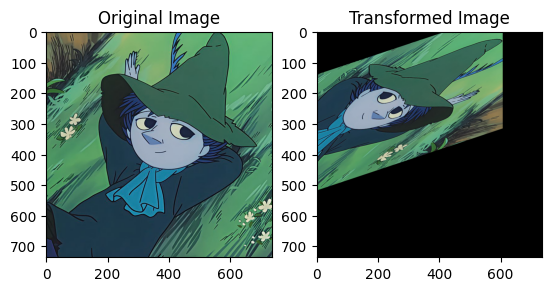

In [22]:
img = cv2.imread("images/Snufkin.jpg")
h, w = img.shape[:2]


pts1 = np.float32([[100,350],[100,90],[490,350]])
pts2 = np.float32([[200,400],[500,300],[200,200]])


M = cv2.getAffineTransform(pts1,pts2)
dst = cv2.warpAffine(img,M,(w,h))

plt.subplot(121); plt.imshow(img); plt.title("Original Image")
plt.subplot(122); plt.imshow(dst); plt.title("Transformed Image")

## Projective Transformation
A projective transformation, also called a perspective transformation or homography, is a geometric transformation that maps points from one plane to another while preserving straight lines but not parallelism or ratios.

Unlike affine transformations, projective transformations can model perspective effects, such as:

- Objects appearing smaller when farther away

- Converging parallel lines (e.g., road lanes, building edges)

- Viewpoint changes between cameras

In [ ]:
img = cv2.imread("images/document.jpg")
img = cv2.resize(img, (img.shape[1]//10,img.shape[0]//10))
def draw(event,x,y,flags,params):
    if event == cv2.EVENT_LBUTTONDOWN: # Left mouse button pressed
        cv2.circle(img,(x,y),1,(255,0,0),-1)
        print((x,y))

cv2.namedWindow('image')
cv2.setMouseCallback('image',draw)

while True:
    cv2.imshow('image',img)
    if cv2.waitKey(1) & 0xFF == 27: # Esc key for closing the window
        break

cv2.destroyAllWindows()

(141, 20)
(293, 47)
(8, 199)
(270, 291)


(292, 301)


(<Axes: title={'center': 'Output'}>,
 Text(0.5, 1.0, 'Output'))

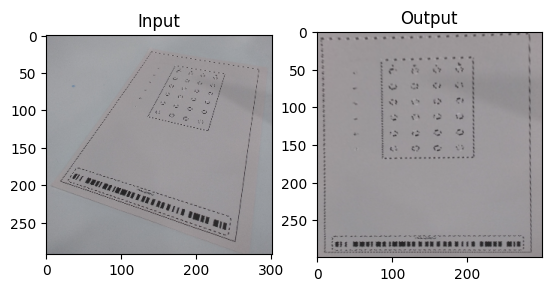

In [32]:
img = cv2.imread("images/document.jpg")
img = cv2.resize(img, (img.shape[1]//10,img.shape[0]//10))
h, w = img.shape[:2]
print(img.shape[:2])


pts1 = np.float32([[140, 18],[294, 46],[7, 199],[267, 291]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
M = cv2.getPerspectiveTransform(pts1,pts2)
dst = cv2.warpPerspective(img,M,(300,300))
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output')

## Harris Corner Detection
Harris measures how much image intensity within a small window changes when you slightly shift the window in different directions.

It uses image gradients, second-moment matrix (also called structure tensor), eigenvalues of that matrix

And it combines them into a corner “response function”:

`R = det(M) − k · (trace(M))²`


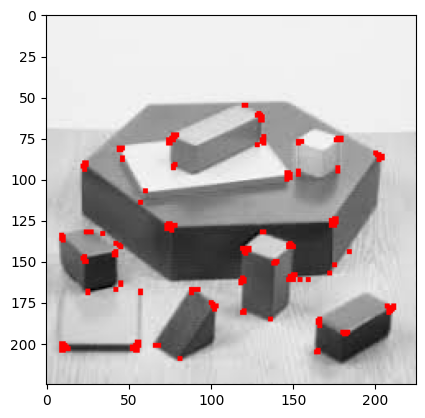

In [19]:
img = cv2.imread("images/corner.jpg")

# convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# convet to float32
gray = np.float32(gray)


block_size = 2 # size of the neighborhood used for computing gradient covariance
ksize = 3 # Sobel kernel size for computing image derivatives
k = 0.04 # Harris free parameter (usually 0.04)

dst = cv2.cornerHarris(gray, block_size, ksize, k)

# Dilate result to mark corners more clearly
dst = cv2.dilate(dst, None)

# Threshold for detecting corners
threshold = 0.01 * dst.max()
result = img.copy()
result[dst > threshold] = [0, 0, 255]  # Mark corners in red

plt.imshow(result[:,:,::-1])

## Shi–Tomasi Corner Detection
Shi–Tomasi Corner Detection is an improvement over the classic Harris Corner Detector designed to identify strong, trackable feature points in an image.

response func:
`R=min(λ1​,λ2​)`

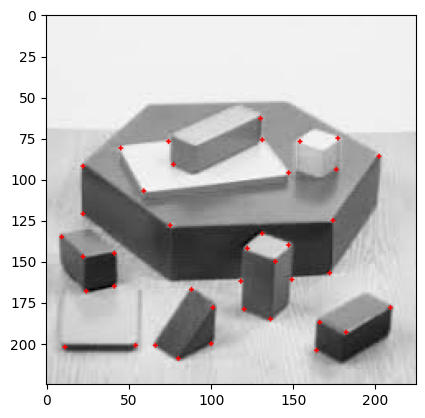

In [ ]:
img = cv2.imread("images/corner.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Shi-Tomasi corner detection
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=40, # Maximum number of corners to return.
    qualityLevel=0.01, # Minimum quality of a corner relative to the strongest one(0-1).
    minDistance=10 # Minimum distance between detected corners to prevent clustering.
)

# Convert to integer coordinates
corners = np.int64(corners)

# Draw corners
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(img, (x, y), 1, (255, 0, 0), -1)

plt.imshow(img)

## SIFT Feature Detection
SIFT (Scale-Invariant Feature Transform) is a feature detection and description algorithm designed to identify distinctive keypoints in images that remain stable under scale changes, rotation, illumination variation, and moderate viewpoint differences. It operates by constructing a scale-space representation of the image using Gaussian blurring, detecting keypoints as extrema in the Difference of Gaussians (DoG), refining them to remove unstable points, assigning dominant orientations to achieve rotation invariance, and finally generating a 128-dimensional descriptor vector that captures the local gradient distribution around each keypoint. This combination of scale invariance, orientation normalization, and highly distinctive descriptors makes SIFT extremely reliable for feature matching tasks such as panorama stitching, object recognition, 3D reconstruction, and visual SLAM. Although computationally heavier than modern alternatives like ORB, SIFT remains one of the most robust and historically significant algorithms in classical computer vision.

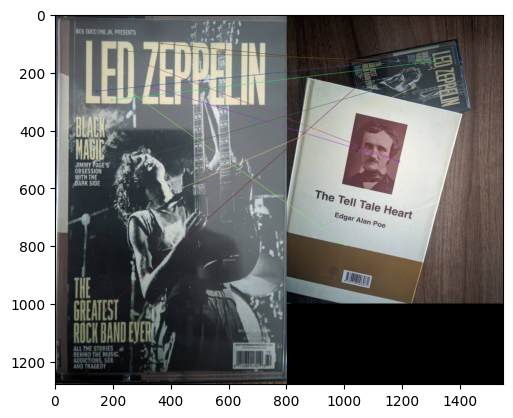

In [25]:
img1 = cv2.imread("images/feature1.jpg")
gray1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)

img2 = cv2.imread("images/feature2.jpg")
gray2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
# Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)

# BruteForceMatcher
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=False)
# match descriptors
matches = bf.match(descriptors1, descriptors2)
matches = sorted(matches, key= lambda x:x.distance)

# draw first 10 matches
result = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches[:10], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(result[...,::-1])


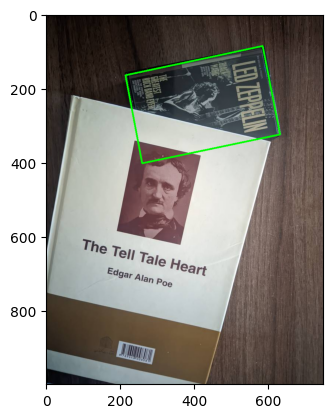

In [ ]:
img1 = cv2.imread("images/feature1.jpg") # Object image
img2 = cv2.imread("images/feature2.jpg")  # Scene image

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Use FLANN matcher (Fast Library for Approximate Nearest Neighbors.)
# better than bruteforce
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(des1, des2, k=2)

# Lowe's Ratio Test
good = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good.append(m)

# Minimum matches needed
MIN_MATCH_COUNT = 10

if len(good) > MIN_MATCH_COUNT:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    # Compute homography using RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h, w = gray1.shape
    pts = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
    dst = cv2.perspectiveTransform(pts, H)

    img2_detected = cv2.polylines(img2.copy(), [np.int32(dst)], True, (0,255,0), 3)

    plt.imshow(img2_detected[...,::-1])

else:
    print("Not enough matches found")

## ORB Feature Detection
ORB (Oriented FAST and Rotated BRIEF) is a computationally efficient feature detection and description algorithm designed as a fast alternative to SIFT and SURF. It combines the FAST corner detector with a Harris-based ranking method to identify strong keypoints, assigns orientations using intensity centroid calculations to achieve rotation invariance, and generates binary descriptors using the BRIEF method. Because ORB descriptors are binary, feature matching can be performed extremely quickly using Hamming distance, making the algorithm well suited for real-time systems. ORB has become a standard feature extraction method in applications such as visual SLAM, robotics navigation, augmented reality tracking, and mobile computer vision systems where computational efficiency is critical.

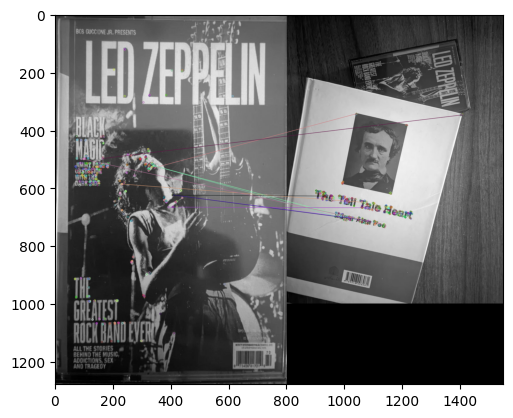

In [ ]:
img1 = cv2.imread("images/feature1.jpg", 0)
img2 = cv2.imread("images/feature2.jpg", 0)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

result = cv2.drawMatches(img1, kp1, img2, kp2, matches[:10], None)

plt.imshow(result)

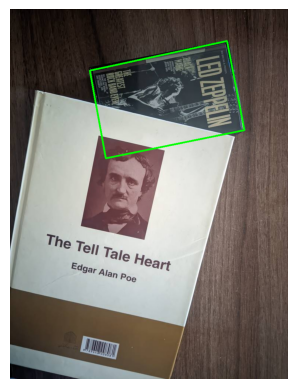

In [20]:
img1 = cv2.imread("images/feature1.jpg") # Object image
img2 = cv2.imread("images/feature2.jpg") # Scene image

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv2.ORB_create(nfeatures=2000)

# Detect keypoints and descriptors
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# ORB uses binary descriptors → use Hamming distance
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

# Sort matches by distance (smaller = better)
matches = sorted(matches, key=lambda x: x.distance)

# Keep best matches
good = matches[:50]

MIN_MATCH_COUNT = 10

if len(good) > MIN_MATCH_COUNT:

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # Compute homography using RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h, w = gray1.shape
    pts = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)

    dst = cv2.perspectiveTransform(pts, H)

    img2_detected = cv2.polylines(
        img2.copy(),
        [np.int32(dst)],
        True,
        (0,255,0),
        3
    )

    plt.imshow(img2_detected[...,::-1])
    plt.axis("off")

else:
    print("Not enough matches found")
